In [ ]:
# Credit Risk Modeling – Probability of Default
# Author: Jorge Mario Martínez
# Objective: Predict loan default probability using classification models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [ ]:
column_names = [
    "Status_Checking_Account",
    "Duration_Months",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment_Since",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "Number_of_Dependents",
    "Telephone",
    "Foreign_Worker",
    "Target"
]

In [ ]:

df = pd.read_csv("german.data", sep=r"\s+", header = None)
df.columns = column_names
df.shape

(1000, 21)

In [ ]:
# Resumen estructural del DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Status_Checking_Account  1000 non-null   object
 1   Duration_Months          1000 non-null   int64 
 2   Credit_History           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_Amount            1000 non-null   int64 
 5   Savings_Account          1000 non-null   object
 6   Employment_Since         1000 non-null   object
 7   Installment_Rate         1000 non-null   int64 
 8   Personal_Status_Sex      1000 non-null   object
 9   Other_Debtors            1000 non-null   object
 10  Residence_Since          1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_Installment_Plans  1000 non-null   object
 14  Housing                  1000 non-null   

In [ ]:
# resumen estadístico descriptivo del DataFrame. (Solo analiza columnas numéricas por defecto.)
df.describe().round(3)

,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Number_of_Dependents,Target
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,20.903,3271.258,2.973,2.845,35.546,1.407,1.155,1.300
std,12.059,2822.737,1.119,1.104,11.375,0.578,0.362,0.458
min,4.000,250.000,1.000,1.000,19.000,1.000,1.000,1.000
25%,12.000,1365.500,2.000,2.000,27.000,1.000,1.000,1.000
50%,18.000,2319.500,3.000,3.000,33.000,1.000,1.000,1.000
75%,24.000,3972.250,4.000,4.000,42.000,2.000,1.000,2.000
max,72.000,18424.000,4.000,4.000,75.000,4.000,2.000,2.000


In [ ]:
df.head()

,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Number_of_Dependents,Telephone,Foreign_Worker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
df["Target"] = df["Target"].map({1: 0, 2: 1})
df.head()

,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Number_of_Dependents,Telephone,Foreign_Worker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [ ]:
df["Target"].value_counts(normalize=True)

,proportion
Target,
0,0.7
1,0.3


EDA (Exploratory Data Analysis):

Fase para entender estructura, calidad y patrones del dataset antes de modelar.

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Status_Checking_Account,0
Duration_Months,0
Credit_History,0
Purpose,0
Credit_Amount,0
Savings_Account,0
Employment_Since,0
Installment_Rate,0
Personal_Status_Sex,0
Other_Debtors,0




### Separar numéricas vs categóricas

Feature types: numéricas (magnitud/escala) vs categóricas (niveles). Determina encoding y preprocesamiento.

In [ ]:
num_cols = ["Duration_Months", "Credit_Amount", "Age", "Installment_Rate", "Residence_Since", "Existing_Credits", "Number_of_Dependents"]
cat_cols = [c for c in df.columns if c not in num_cols + ["Target"]]

len(num_cols), len(cat_cols), cat_cols[:5]

(7,
 13,
 ['Status_Checking_Account',
  'Credit_History',
  'Purpose',
  'Savings_Account',
  'Employment_Since'])

### Distribucion númerica

Skewness / Outliers: distribuciones asimétricas y valores extremos pueden distorsionar modelos.

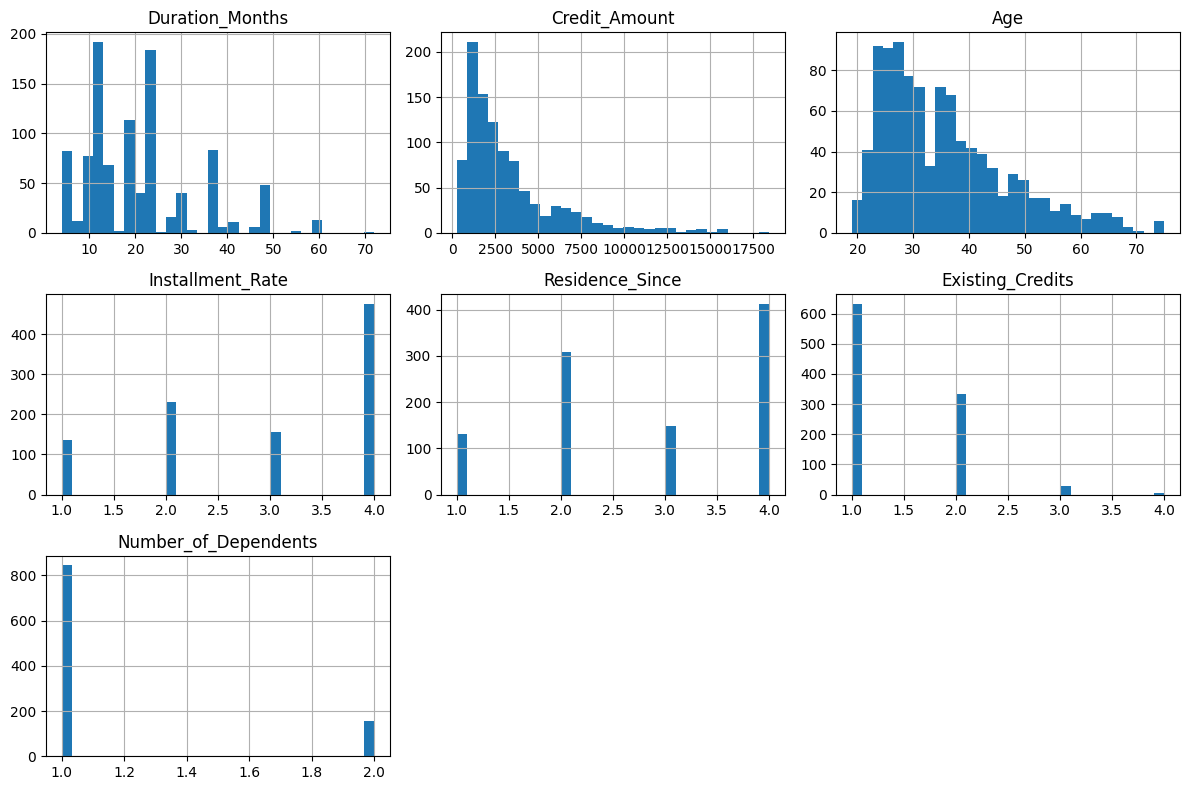

In [ ]:
plt.figure(figsize=(12,8))

for i, c in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    df[c].hist(bins=30)
    plt.title(c)

plt.tight_layout()
plt.show()

### Data Distribution Analysis

* **Duration months:** Variable discreta con alta concentración en prestamos de corto y mediano plazo, con algunos pocos prestamos a largo plazo, presencia de cola derecha moderada.
* **Credit Amount:** Distribución típica de crédito minorista. Gran concetracion de montos bajos ($ < 5000$),con fuerte asimetría positiva (right-skewed) dado a este comportamiento es una candidata potencial a transformación logarítmica si se desea mejorar estabilidad en modelos lineales. Posibles outliers naturales (no errores).
* **Age:** Distribucion relativamente unimodal, Concentración entre $20 - 40$ años y pocos valores $(> 60)$, lo cual indica un perfil joven predominante en dataset. No se observan valores extremos problemáticos.
* **Installment Rate:** Variable categórica ordinal ($1 - 4$) con una mayor concentración en la categoría 4, debe tratarse como variable categórica ordinal.
* **Residence since:** Variable categórica ordinal, concentración fuerte en $2$ y $4$. Podría estar asociada con estabilidad financiera
* **Existing credits:** Variable altamente desbalanceada. Altísima concentración en $1$ crédito existente con muy pocos casos con $3$ o $4$.

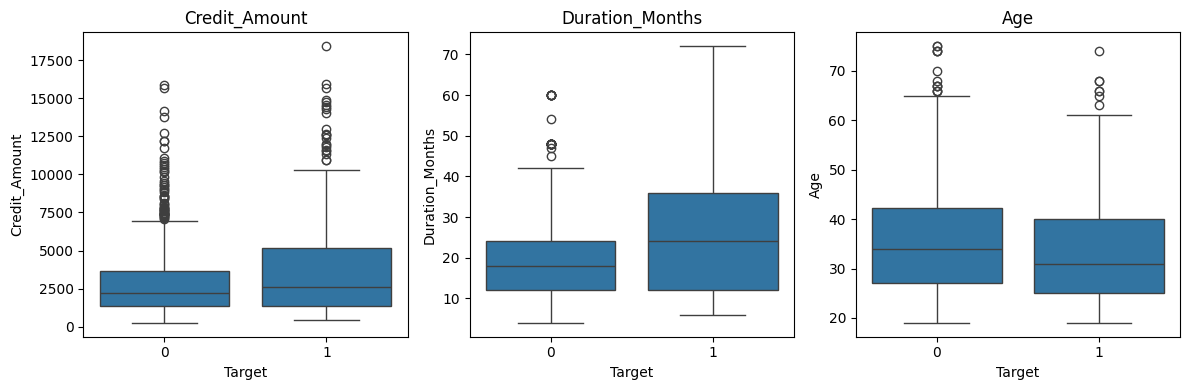

In [ ]:
plt.figure(figsize=(12,4))

for i, c in enumerate(["Credit_Amount", "Duration_Months", "Age"], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x = "Target", y = c, data = df)
    plt.title(c)

plt.tight_layout()
plt.show()

* **Credit Amount vs Target:** La mediana de Credit_Amount es mayor en clase $1$ (default). Mayor dispersion y mayor cantidad de valores extremos en a clase $1$, esto sugiere que los clientes que incumplen tienden a solicitar montos más altos. Ademas, sugiere aumento del riesgo con mayor capital financiado. (Distribución altamente asimétrica.)
* **Duration Months vs Target:** Mediana significativamente mayor en clase 1. Mayor rango intercuartílico en clase 1 y más préstamos largos en default. Duraciones más largas están asociadas con mayor probabilidad de incumplimiento. Insight clave: Duration aparece como variable estructuralmente relevante para riesgo.
* **Age vs Target:** Medianas similares. Ligera tendencia a menor edad en clase 1. La edad no parece ser un driver fuerte de default en este dataset.

### Default rate por categorías

Default rate por segmento: proporción de default dentro de una categoría; útil para decisiones de riesgo y segmentación.

In [ ]:
def default_rate_by(col):
    tmp = df.groupby(col)["Target"].mean().sort_values(ascending=False)
    return tmp

# Funciona correctamente solo si Target está codificada como 0/1
default_rate_by("Credit_History").head(10)

,Target
Credit_History,
A30,0.625000
A31,0.571429
A32,0.318868
A33,0.318182
A34,0.170648


* **Credit History** parece ser uno de los drivers más fuertes del modelo, esto es coherente con teoría económica: Historial pasado es predictor fuerte de comportamiento futuro.

* El historial crediticio muestra un fuerte poder discriminatorio. Las categorías A30 y A31 presentan tasas de incumplimiento superiores al 57%, mientras que A34 exhibe una probabilidad de default significativamente menor (17%). Esto confirma que el comportamiento crediticio previo es un factor determinante del riesgo.

* El historial crediticio es uno de los principales determinantes del riesgo, mostrando diferencias sustanciales en tasas de incumplimiento entre categorías.

In [ ]:
default_rate_by("Purpose").head(10)

,Target
Purpose,
A46,0.440000
A410,0.416667
A40,0.380342
A45,0.363636
A49,0.350515
A44,0.333333
A42,0.320442
A43,0.221429
A41,0.165049


Algunas categorías de *Purpose* del crédito presentan tasas de default claramente superiores al promedio ($≥ 38 - 44%$).
Esto indica que el destino del crédito influye en la probabilidad de incumplimiento.

Dependiendo de la codificación original del dataset:

*	Algunos propósitos pueden estar asociados a mayor incertidumbre financiera.
*	Otros pueden representar gastos no productivos.

**Segmentos de menor riesgo**

A41 y A48 muestran default rates muy bajos ($≈ 11 - 16%$).

Esto sugiere:

* Propósitos más estables o asociados a mejor perfil financiero.
* Posible menor riesgo estructural.

El destino del crédito influye en la probabilidad de incumplimiento, aunque su efecto es inferior al observado en el historial crediticio.

## Validación estructural

In [ ]:
df.describe().round(2)

,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Number_of_Dependents,Target
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16,0.30
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36,0.46
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00,0.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00,0.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00,0.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00,1.00


* **¿Credit_Amount tiene valores extremos?** Si, probablemente hay valores extremos en Credit_Amount. observamos el $50%$ y $75%$ y lo comparamos con el valor máximo, este valor max esta alejado, lo cual indica, Cola derecha larga (right-skewed distribution) Posibles outliers en montos altos, En crédito real esto es normal: Pocos préstamos grandes, Muchos préstamos pequeños, pero no son errores, son parte natural del negocio.

* **¿Duration_Months tiene rango amplio?** El valor min es $4$ y el max es $72$, no es extremo, pero se debe evaluar, si esta concetrado en ciertos valores. Si la distribución está concentrada en $12 - 24$ meses y pocos en $60 - 72$: Eso sugiere mayor riesgo potencial en préstamos largos. Cuanto más largo el plazo:

    * Mayor tiempo de exposición.
    * Mayor probabilidad de evento adverso
    * Más eventos pueden ocurrir

Esto es hipótesis económica. NO estadística


* **¿Age parece razonable?** Si, no hay valores absurdos la edad min es $19$ y la max es $75$

## Correlaciones numéricas

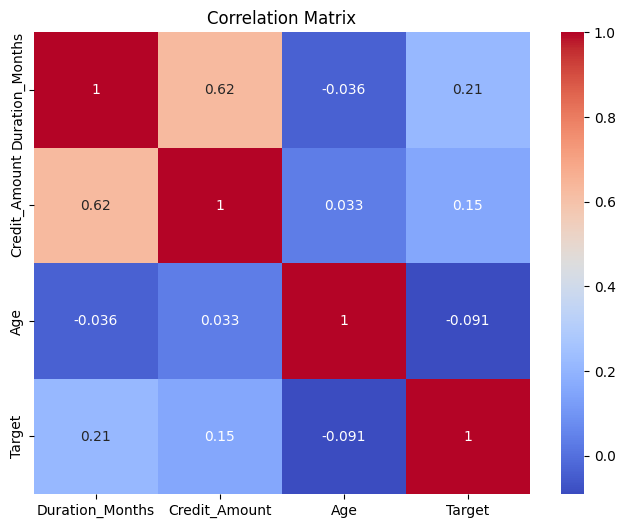

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[["Duration_Months","Credit_Amount","Age","Target"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

* **¿Alguna variable tiene correlación moderada con Target?** La duracion en meses presenta una correlacion moderada-alta con Target. Préstamos más largos tienden a tener montos mayores.

* **¿Duration y Credit_Amount están correlacionadas?** Si, presentan correlacion baja positva, es decir cuando aumenta la duracion, puede aumentar el valor del credito.
* Duration, age y Credit amount: Son correlaciones débiles, Pero eso es normal en problemas reales de riesgo. Ninguna variable individualmente tiene correlación alta con el default.
* En datasets reales de crédito: Correlaciones simples rara vez superan $0.3$. Si vieras correlación $0.8$ con Target: Sería sospechoso (data leakage).
* Numerical variables show moderate inter-correlation between loan duration and credit amount ($ρ = 0.62$), suggesting structural relationship. However, linear correlations with the target remain weak ($ρ ≤ 0.21$), indicating that default prediction likely depends on multivariate interactions rather than single-variable linear effects.
* Moderate correlation between duration and credit amount ($ρ = 0.62$) may introduce partial multicollinearity in the logistic model, potentially affecting coefficient stability while preserving predictive performance.

## Default Rate por Segmentos Clave

* Default Rate: Proporción de clientes en default dentro de un grupo.
* Binning: Agrupar variable continua en intervalos para análisis segmentado.
* Correlación: Medida lineal de asociación entre variables.


In [ ]:
df.groupby("Duration_Months")["Target"].mean().sort_values(ascending=False).head(7)

,Target
Duration_Months,
40,1.000000
72,1.000000
45,0.800000
48,0.583333
16,0.500000
54,0.500000
60,0.461538


In [ ]:
df.groupby("Duration_Months")["Target"] \
  .agg(["mean","count"]) \
  .sort_values("mean", ascending=False) \
  .head(7)

,mean,count
Duration_Months,,
40,1.000000,1
72,1.000000,1
45,0.800000,5
48,0.583333,48
16,0.500000,2
54,0.500000,2
60,0.461538,13


Cuando analizamos por valores exactos podemos caer el conclusiones erronas, dado que algunas duraciones (por ejemplo 40 o 72 meses) pueden tener muy pocos registros. Si solo hay: 1 préstamo de 72 meses y ese cliente hizo default, entonces  $\text{Defaul rate} = \frac{1}{1}=1$ Eso no significa que $72$ meses sea extremadamente riesgoso.# Significa que el tamaño de muestra es pequeño. La mejor forma de analizar la duracion es agrupando en bins, no por valor exacto.

### Analisis por bins: Duration Months

In [ ]:
df["Duration_bin"] = pd.cut(df["Duration_Months"], bins = 4)
df.groupby("Duration_bin", observed=True)["Target"].agg(["mean","count"])

,mean,count
Duration_bin,,
"(3.932, 21.0]",0.243151,584
"(21.0, 38.0]",0.343465,329
"(38.0, 55.0]",0.520548,73
"(55.0, 72.0]",0.500000,14


* **¿Mayor duración implica mayor default?** Si, con los resultados obtenidos podemos inferir que a mayor duracion, es posible tener mayor default.
* **¿Hay segmento claramente más riesgoso?** Si, el segmento $[38 - 55]$, tiene un rate default de $52%$ muy relevante con respecto al promedio (aprox. $30%$)

### Analisis Bins: Credit Amount por cuartiles

In [ ]:
df["Amount_bin"] = pd.qcut(df["Credit_Amount"], q=4)
df.groupby("Amount_bin", observed=True)["Target"].agg(["mean","count"])

,mean,count
Amount_bin,,
"(249.999, 1365.5]",0.308,250
"(1365.5, 2319.5]",0.248,250
"(2319.5, 3972.25]",0.224,250
"(3972.25, 18424.0]",0.420,250


* **¿Mayor monto implica mayor default?** Es este caso, la probabilidad de hacer prestamos grandes tambien implica mayor defualt, aunque tambien tenemos un grupo de pequenos montos con default.
* **¿Hay segmento claramente más riesgoso?** Si, el segmento $[3972.25 - 18424.00]$, tiene un rate default de $42%$ confirmando que a mayor cantidad de dinero prestado mayor es el riesgo.

### Analiza categorías críticas

In [ ]:
df.groupby("Credit_History")["Target"].agg(["mean","count"]).sort_values("mean", ascending=False)

,mean,count
Credit_History,,
A30,0.625000,40
A31,0.571429,49
A32,0.318868,530
A33,0.318182,88
A34,0.170648,293


De acuerdo a los resultados, el segménto mas riesgoso es A30 y A31.

Although the category labeled “critical account” may intuitively suggest higher risk, empirical analysis shows that in this dataset A34 exhibits the lowest default rate (17%), while A30 and A31 present significantly higher risk levels.

# **TRANSICIÓN A MODELADO**


In [ ]:
X = df.drop("Target", axis=1)
y = df["Target"]

2.  Identificar variables categóricas y numéricas

In [ ]:
num_cols = [
    "Duration_Months",
    "Credit_Amount",
    "Installment_Rate",
    "Residence_Since",
    "Age",
    "Existing_Credits",
    "Number_of_Dependents"
]

cat_cols = [col for col in X.columns if col not in num_cols]

3.  One-Hot Encoding (profesional)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

### One-Hot Encoding

Transforma variables categóricas en variables binarias.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

### Train / Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## **Modelo Baseline (Threshold 0.5): Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Duration_Months',
                                                   'Credit_Amount',
                                                   'Installment_Rate',
                                                   'Residence_Since', 'Age',
                                                   'Existing_Credits',
                                                   'Number_of_Dependents']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Status_Checking_Account',
                                                   'Credit_History', 'Purpose',
                                                   'Savings_Account',
                                                   'Employment_Since',
                                                   'Personal_Status_Sex',
                                                   'Other_Debtors', 'Property',
                                                   'Other_Installment_Plans',
                                                   'Housing', 'Job',
                                                   'Telephone',
                                                   'Foreign_Worker',
                                                   'Duration_bin',
                                                   'Amount_bin'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Evaluación correcta (no solo accuracy)**

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       210
           1       0.68      0.51      0.58        90

    accuracy                           0.78       300
   macro avg       0.74      0.70      0.72       300
weighted avg       0.77      0.78      0.77       300

AUC: 0.8086772486772487
Confusion Matrix:
 [[188  22]
 [ 44  46]]


* AUC: El modelo discrimina razonablemente (AUC $0.80$). El modelo separa razonablemente bien los buenos vs malos. No es excelente $(>0.90)$, pero es sólido para un baseline en crédito real.
    * Costo esperado: Costo $= 5(44) + 22 = 242 $   
* Recall(dafault) = $0.51$. Detecta solo el $51%$ de los defaulters. Eso significa: De $90$ clientes que realmente iban a incumplir, detecto $46$ y dejo escapar $44$ clientes. Esto es elevado en el contexto bancario.
* La cantidad de falsos negativos (FN) es $44$ clientes que realmente iban a incumplir, el modelo los clasificó como buenos. En banca, esto es el error más costoso.
* AUC measures the model’s ability to rank observations correctly, whereas false negatives depend on the chosen decision threshold.
* Imagina que todos los defaulters tienen probabilidad entre $0.35$ y $0.49$. El modelo los separa bien (ranking correcto). Pero si el threshold es $0.5$: Todos serán clasificados como no-default.

* The logistic regression model achieves reasonable overall discrimination (AUC ≈ 0.81), but recall for the default class remains moderate (51%). This implies a significant number of high-risk borrowers are not being detected, which could lead to financial losses in a real credit approval setting.
3.	¿Cuántos falsos negativos tienes?

### Ajustar Threshold para mejorar Recall

In [ ]:
import numpy as np

threshold = 0.35
y_pred_adjusted = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_adjusted))
print(confusion_matrix(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       210
           1       0.59      0.71      0.64        90

    accuracy                           0.76       300
   macro avg       0.73      0.75      0.73       300
weighted avg       0.78      0.76      0.77       300

[[165  45]
 [ 26  64]]


Al bajar el threshold: Detectamos más defaulters (recall) pero clasificas más buenos como malos, antes dejaba pasar $44$ defaulters ahora solo $26$, la reducción de Falsos Negativos fue de $\frac{44-26}{44} = $0.41$  $

* Al reducir el umbral de decisión, el recall para la clase de incumplimiento (default) aumentó del 51% al 71%, reduciendo significativamente los falsos negativos. Aunque la exactitud (accuracy) general disminuyó ligeramente, el modelo quedó mejor alineado con las prioridades de riesgo del negocio al minimizar errores de clasificación de alto costo.



## Optimizar el threshold

* Optimizar threshold matemáticamente (curve precision-recall)
* Incorporar matriz de costos explícitamente y minimizar costo esperado

### Optimizar threshold matemáticamente (curve precision-recall)

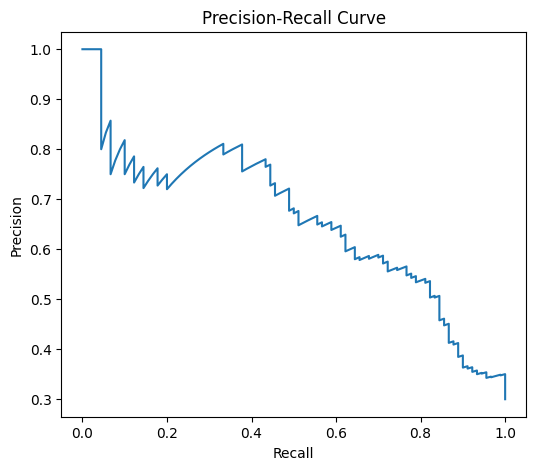

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

#### threshold óptimo para F1

In [ ]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)

best_index = np.argmax(f1_scores)
best_threshold_f1 = thresholds[best_index]

best_threshold_f1

np.float64(0.3044622434088064)

Luego evaluamos:

In [ ]:
y_pred_f1 = (y_prob >= best_threshold_f1).astype(int)

print(classification_report(y_test, y_pred_f1))
print(confusion_matrix(y_test, y_pred_f1))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81       210
           1       0.57      0.77      0.65        90

    accuracy                           0.75       300
   macro avg       0.72      0.76      0.73       300
weighted avg       0.79      0.75      0.76       300

[[157  53]
 [ 21  69]]


### Optimización con matriz de costos

In [ ]:
costs = []

for t in thresholds:
    y_pred_temp = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_temp).ravel()

    cost = 5*fn + 1*fp
    costs.append(cost)

costs = np.array(costs)

best_index_cost = np.argmin(costs)
best_threshold_cost = thresholds[best_index_cost]

best_threshold_cost

np.float64(0.22767326455906406)

Evaluamos

In [ ]:
y_pred_cost = (y_prob >= best_threshold_cost).astype(int)

print(classification_report(y_test, y_pred_cost))
print(confusion_matrix(y_test, y_pred_cost))

              precision    recall  f1-score   support

           0       0.91      0.65      0.76       210
           1       0.51      0.84      0.63        90

    accuracy                           0.71       300
   macro avg       0.71      0.75      0.69       300
weighted avg       0.79      0.71      0.72       300

[[136  74]
 [ 14  76]]


1.	¿El threshold por costo es más bajo?

$costo= 0.228 < F1 = 0.304 < default= 0.5$
Cuanto más costosa es la FN, más bajo se vuelve el threshold.
  
El modelo optimizado por costo:

	*	Detecta 84% de los defaulters.
	*	Reduce FN en 33% respecto a F1.
	*	Aumenta rechazos de buenos clientes.
	*	Reduce pérdida financiera esperada.

Este modelo es más conservador.

* Insight profundo

El threshold por costo es menor porque:

Para compensar que FN cuesta 5 veces más,
el modelo debe clasificar más observaciones como default.

Eso matemáticamente empuja el corte hacia la izquierda.

* Diagnóstico final:

	*	F1 threshold optimiza balance estadístico.
	*	Cost threshold optimiza decisión económica.
	*	Para banca real → el segundo es más coherente.

##  Interpretabilidad (Logistic Regression)


In [ ]:
# Extraer modelo entrenado
log_model = model.named_steps["classifier"]

# Obtener nombres de columnas transformadas
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Obtener coeficientes
coefficients = log_model.coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values("Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
38,cat__Property_A124,0.820991
20,cat__Purpose_A46,0.676703
0,num__Duration_Months,0.510101
2,num__Installment_Rate,0.286850
10,cat__Credit_History_A31,0.278633
34,cat__Other_Debtors_A102,0.273411
5,num__Existing_Credits,0.211084
37,cat__Property_A123,0.176207
1,num__Credit_Amount,0.164163
6,num__Number_of_Dependents,0.115799


In [ ]:
coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df.head(10)

,Feature,Coefficient,Odds_Ratio
38,cat__Property_A124,0.820991,2.272752
20,cat__Purpose_A46,0.676703,1.967382
0,num__Duration_Months,0.510101,1.665459
2,num__Installment_Rate,0.286850,1.332224
10,cat__Credit_History_A31,0.278633,1.321322
34,cat__Other_Debtors_A102,0.273411,1.314440
5,num__Existing_Credits,0.211084,1.235016
37,cat__Property_A123,0.176207,1.192685
1,num__Credit_Amount,0.164163,1.178407
6,num__Number_of_Dependents,0.115799,1.122771


* cat__Property_A124

Coef = 0.8209
OR = 2.27

Interpretación:

Clientes con esa categoría de propiedad tienen:

2.27 \times

más odds de default que la categoría base. Eso es fuerte. Es el driver más potente en tu modelo.

* cat__Purpose_A46

$$OR = 1.97$$

Ese propósito casi duplica el riesgo frente a la categoría base.

Impacto alto.

* Duration_Months

$Coef = 0.510$
$$OR = 1.66$$

Interpretación correcta:

Por cada unidad adicional (según cómo esté escalado): Las odds de default aumentan 66%.

* Si está estandarizado, significa por 1 desviación estándar.
* Si no está escalado, debes tener cuidado con interpretación.

* Installment_Rate

$$OR = 1.33$$

Mayor proporción de cuota → mayor presión financiera → mayor riesgo.

Coherente económicamente.

* Credit_History_A31

$$OR = 1.32$$

Confirma lo que viste en EDA: Esa categoría es riesgosa.

El modelo lo confirma multivariadamente.

* Variable Credit_Amount

$$OR = 1.18$$

Incremento moderado del riesgo.

Pero observa:

En correlación simple no era tan fuerte. Eso demuestra algo importante: Relación marginal ≠ relación multivariada.

**Insights**

1.	Propiedad y propósito son drivers estructurales.
2.	Duración es variable cuantitativa fuerte.
3.	Historial crediticio mantiene poder incluso controlando otras variables.
4.	Ningún OR es exageradamente alto (>5), lo que sugiere modelo estable.

#### ¿El costo total realmente disminuyó respecto al threshold 0.5?


In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
cost_default = 5*fn + 1*fp

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_cost).ravel()
cost_cost_opt = 5*fn + 1*fp

cost_default, cost_cost_opt

(np.int64(242), np.int64(144))

Al ser menor el segundo se tomo una buena decisión.

## Comparación con otros modelos

* Random Forest.
* XGboots

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Duration_Months',
                                                   'Credit_Amount',
                                                   'Installment_Rate',
                                                   'Residence_Since', 'Age',
                                                   'Existing_Credits',
                                                   'Number_of_Dependents']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Status_Checking_Account',
                                                   'Credit_History', 'Purpose',
                                                   'Savings_Account',
                                                   'Employment_Since',
                                                   'Personal_Status_Sex',
                                                   'Other_Debtors', 'Property',
                                                   'Other_Installment_Plans',
                                                   'Housing', 'Job',
                                                   'Telephone',
                                                   'Foreign_Worker',
                                                   'Duration_bin',
                                                   'Amount_bin'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

Evaluar

In [ ]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.93      0.85       210
           1       0.71      0.38      0.49        90

    accuracy                           0.77       300
   macro avg       0.74      0.66      0.67       300
weighted avg       0.76      0.77      0.74       300

AUC: 0.7858730158730158
[[196  14]
 [ 56  34]]


Primero recordemos tu Logistic baseline (threshold 0.5):

Logistic:

*	AUC ≈ 0.8009
*	Recall clase 1 = 0.52
*	FN = 43
*	Accuracy = 0.78
*	Matriz:

$$\begin{bmatrix}
187 & 23 \\
43 & 47
\end{bmatrix}$$

Ahora tu Random Forest:

RF:

*	AUC = 0.7862
*	Recall clase 1 = 0.37
*	FN = 57
*	Accuracy = 0.76
*	Matriz:

$$\begin{bmatrix}
196 & 14 \\
57 & 33
\end{bmatrix}$$


**Interpretación:**

La Logistic discrimina ligeramente mejor. RF no mejora ranking. Conclusión: RF no aporta ventaja en capacidad de separación.

Observemos:

RF:

*	Specificity = 0.93 (muy alto)
*	Precision clase 1 = 0.70 (decente)
*	Recall muy bajo

Esto indica: RF es conservador. Clasifica pocos como default. Eso mejora estabilidad comercial, pero empeora control de riesgo.

Si aplicas class_weight=‘balanced’ en RF, ¿qué esperarías que ocurra con:
* Recall clase 1?
* FN?
* Precision?


Si configuras class_weight="balanced" en Random Forest, lo que haces es penalizar más los errores en la clase minoritaria (default) durante el entrenamiento. En tu dataset, default es ~30%, así que el modelo aprende a “tomarse más en serio” esa clase.

Qué cambia y por qué

1) Recall clase 1 (default) — debería SUBIR
	*	El modelo empezará a predecir más casos como default.
	*	Eso reduce FN (malos aprobados).
	*	Matemáticamente, si $FN\downarrow$, entonces:

$Recall=\frac{TP}{TP+FN}\uparrow$

2) FN — deberían BAJAR

3)
	*	Al clasificar más como default, se te van a “escapar” menos defaulters.
	*	En riesgo, esto es lo deseable (porque FN es el error caro).

4) Precision clase 1 — probablemente BAJE
	*	Como ahora marcas más clientes como default, también vas a marcar erróneamente más buenos como malos (sube FP).
	*	Si $FP\uparrow$, entonces:

$Precision=\frac{TP}{TP+FP}\downarrow$

5) Accuracy — probablemente BAJE
	*	Accuracy suele caer cuando dejas de favorecer a la clase mayoritaria.
	*	No es malo: solo significa que ya no estás optimizando “aciertos globales”, sino control de riesgo.

6) AUC — puede subir un poco o quedarse similar
	*	AUC mide ranking, no umbral.
	*	class_weight puede mejorar separación, pero no siempre; muchas veces cambia más la frontera de decisión que el ranking.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_bal = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

rf_bal.fit(X_train, y_train)

y_prob = rf_bal.predict_proba(X_test)[:,1]
y_pred = rf_bal.predict(X_test)

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.95      0.85       210
           1       0.74      0.36      0.48        90

    accuracy                           0.77       300
   macro avg       0.76      0.65      0.67       300
weighted avg       0.77      0.77      0.74       300

AUC: 0.7934126984126983
[[199  11]
 [ 58  32]]


###  XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        use_label_encoder=False
    ))
])

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:39:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Duration_Months',
                                                   'Credit_Amount',
                                                   'Installment_Rate',
                                                   'Residence_Since', 'Age',
                                                   'Existing_Credits',
                                                   'Number_of_Dependents']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Status_Checking_Account',
                                                   'Credit_History', 'Purpose',
                                                   'Savings_Account',
                                                   'Employment_Since',
                                                   'Personal_Stat...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=None,
                               num_parallel_tree=None, ...))])

Evaluar

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))
print(confusion_matrix(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       210
           1       0.62      0.47      0.53        90

    accuracy                           0.75       300
   macro avg       0.71      0.67      0.68       300
weighted avg       0.74      0.75      0.74       300

AUC: 0.7885185185185186
[[184  26]
 [ 48  42]]


## optimizamos threshold para XGBoots model.

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

costs = []

for t in thresholds:
    y_temp = (y_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_temp).ravel()
    cost = 5*fn + 1*fp
    costs.append(cost)

costs = np.array(costs)
best_index = np.argmin(costs)
best_threshold_xgb = thresholds[best_index]

best_threshold_xgb

np.float32(0.072709605)

### Evaluamos XGBoots

In [ ]:
y_pred_cost_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

print(classification_report(y_test, y_pred_cost_xgb))
print(confusion_matrix(y_test, y_pred_cost_xgb))

              precision    recall  f1-score   support

           0       0.93      0.45      0.61       210
           1       0.42      0.92      0.58        90

    accuracy                           0.59       300
   macro avg       0.68      0.69      0.59       300
weighted avg       0.78      0.59      0.60       300

[[ 95 115]
 [  7  83]]


XGBoost no genera mejora económica significativa respecto a Logistic Regression.

Para lograr alta sensibilidad, requiere un threshold muy bajo, lo que incrementa sustancialmente los falsos positivos y reduce estabilidad comercial.

Dado que:

	*	El costo total es similar.
	*	La regresión logística ofrece mayor interpretabilidad.
	*	El entorno crediticio suele ser regulado.

La regresión logística es preferible como modelo principal.

XGBoost podría considerarse en contextos donde el apetito de riesgo sea extremadamente conservador y la reducción máxima de falsos negativos sea prioritaria sobre eficiencia comercial.

In [1]:
# ───────────────────────────────────────────────────────────────
# 1. Precision-Recall Curve (muy relevante por el imbalance)
# ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 6))

# Puedes graficar varios modelos si tienes sus probabilidades
for name, y_prob in [
    ('Logistic Regression', y_pred_f1),   # <--- asegúrate que esta variable exista
    ('XGBoost', y_prob_rf),
    # ('Random Forest', y_prob_rf),             # descomenta si la tienes
]:
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, lw=2.2, label=f'{name}')

plt.xlabel('Recall (Sensibilidad - Tasa de detección de defaults)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve – Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar
# plt.savefig('reports/figures/precision_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# ───────────────────────────────────────────────────────────────
# 2. Cost vs Threshold Plot (para XGBoost – puedes repetir para otros modelos)
# ───────────────────────────────────────────────────────────────
costs = []
thresholds = np.linspace(0.01, 0.99, 200)   # más puntos para curva suave

for t in thresholds:
    y_temp = (y_prob_xgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_temp).ravel()
    cost = 5 * fn + 1 * fp
    costs.append(cost)

costs = np.array(costs)

plt.figure(figsize=(9, 6))
plt.plot(thresholds, costs, color='teal', lw=2.5, label='Costo esperado (5×FN + 1×FP)')
plt.axvline(x=best_threshold_xgb, color='red', linestyle='--',
            label=f'Óptimo (~{best_threshold_xgb:.3f}) – Costo ${min(costs)}')
plt.xlabel('Threshold de probabilidad', fontsize=12)
plt.ylabel('Costo esperado total', fontsize=12)
plt.title('Costo Esperado vs Threshold – XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# plt.savefig('reports/figures/cost_vs_threshold_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ───────────────────────────────────────────────────────────────
# 3. Confusion Matrices comparativas en varios thresholds
# ───────────────────────────────────────────────────────────────
thresholds_to_show = [0.5, best_threshold_xgb, 0.30]  # default, óptimo costo, intermedio
fig, axes = plt.subplots(1, len(thresholds_to_show), figsize=(15, 5))

for ax, thresh in zip(axes, thresholds_to_show):
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'Threshold = {thresh:.3f}\nFN={cm[1,0]} | FP={cm[0,1]}')

plt.suptitle('Matriz de Confusión – XGBoost en diferentes thresholds', fontsize=16, y=1.05)
plt.tight_layout()

# plt.savefig('reports/figures/confusion_matrices_thresholds_xgb.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ───────────────────────────────────────────────────────────────
# Matriz de Confusión comparativa – LOGISTIC REGRESSION
# (en los tres thresholds clave que ya documentaste)
# ───────────────────────────────────────────────────────────────

# Asegúrate de tener estas variables:
# y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]   # si no está, ejecútalo antes

thresholds_logistic = [0.50, 0.30, 0.22]  # default, F1-opt, Cost-opt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, thresh in zip(axes, thresholds_logistic):
    y_pred_thresh = (y_prob_lr >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred_thresh)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Good (0)', 'Bad (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(f'Threshold = {thresh:.2f}\nFN = {cm[1,0]} | FP = {cm[0,1]}\nCost = {5*cm[1,0] + cm[0,1]}')

plt.suptitle('Matriz de Confusión – Logistic Regression en diferentes thresholds',
             fontsize=16, y=1.05)
plt.tight_layout()

plt.show()